# 08 · How certain are the results, and do the operational claims hold?

**Requirements 3 and 4, made sturdier.** Notebook 06 reports point estimates and their spread over
three training seeds. Seed spread says how much the *model* varies. It says nothing about how much
the numbers would move with a different stretch of days or different homes, and that is what a
utility needs to know. This notebook adds both, and then tests the operational claims that
`Recommendation.md` relies on.

| | |
|---|---|
| **Input** | the frozen primary model (Seq2Point three-seed ensemble, W = 81) and the splits of notebook 03 |
| **Output** | `artifacts/tables/nb08_*.csv`, `artifacts/metrics/nb08_summary.json`, figures `nb08_*` |
| **Run time** | about 5 minutes |

**Nothing here selects or changes a model.** The predictions are recomputed from the saved
checkpoints, the same predictions notebook 06 scored. The one tuned quantity, the threshold that
labels a *predicted* wash as heated, is chosen on the validation home and only then applied to the
test homes.

**Methods.**
* *Within a home (the primary result):* whole days are resampled with replacement, 1,000 times,
  and every metric is recomputed. Minutes within a day are strongly dependent (one wash spans an
  hour or two), so resampling minutes would understate the uncertainty; days are the natural
  block. As a robustness check, a stationary bootstrap (Politis & Romano 1994) resamples runs of
  consecutive days with a mean length of 7, which also keeps any week-to-week dependence.
* *Across homes (a rough guide):* a cluster bootstrap resamples whole homes and keeps all their
  days (Field & Welsh 2007). Six homes allow only 462 distinct resamples, and few-cluster
  intervals are known to be unreliable (Cameron, Gelbach & Miller 2008). This interval is for the
  *average* over homes like these; a single new home varies far more (section 1).
* *Intervals:* 95 % percentile intervals (Efron & Tibshirani 1993). The day-level statistics
  reproduce the point metrics of notebook 06 exactly (`tests/test_uncertainty.py`).


In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr

from refit_nilm import config as C
from refit_nilm import cycles
from refit_nilm import datasets as D
from refit_nilm import metrics, plots
from refit_nilm import train as T
from refit_nilm import uncertainty as U

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 160, "display.max_columns", 30)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
W = 81
N_BOOT = 1000
frames, corpora, stats = D.prepare([W])
cp, st = corpora[W], stats[W]
models = {s: T.load_run(C.MODEL_DIR / f"m2_seq2point_w{W}_s{s}.pt", device=DEVICE)[0] for s in C.SEEDS}
src = T.WindowSource(cp, st, DEVICE)
UNSEEN = [C.TEST_HOUSE] + C.EXTRA_UNSEEN_HOUSES
SUMMARY: dict = {"n_boot": N_BOOT, "unseen_homes": UNSEEN}


def ensemble_series(split: str, house: int) -> tuple[pd.Series, pd.Series]:
    starts = cp.starts[split]
    starts = starts[cp.house[starts + W // 2] == house]
    y = D.to_series(cp, starts, cp.wm[starts + W // 2], house)
    p = np.mean([T.predict(m, src, starts, st)["power"] for m in models.values()], axis=0)
    return y, D.to_series(cp, starts, p, house)


series = {("test", h): ensemble_series("test", h) for h in UNSEEN}
series[("val", C.VAL_HOUSE)] = ensemble_series("val", C.VAL_HOUSE)
for h in C.TRAIN_HOUSES:
    series[("seen_test", h)] = ensemble_series("seen_test", h)
print({k: int(v[0].notna().sum()) for k, v in series.items()})

{('test', 8): 691872, ('test', 1): 762593, ('test', 6): 679428, ('test', 10): 660059, ('test', 19): 598016, ('test', 20): 587480, ('val', 18): 553394, ('seen_test', 2): 147288, ('seen_test', 5): 139669, ('seen_test', 7): 126902, ('seen_test', 9): 123453, ('seen_test', 15): 123572, ('seen_test', 16): 118489, ('seen_test', 17): 92512}


## 1. Confidence intervals on the unseen homes

Point estimates are identical to notebook 06 (checked in the first column). The interval is what
changes the reading.

In [2]:
rows, days = [], {}
for h in UNSEEN:
    y, p = series[("test", h)]
    d = U.daily_stats(y, p)
    days[h] = d
    point = U.metrics_from_days(d)
    ci = U.percentile_ci(U.bootstrap_home(d, N_BOOT, seed=h))
    ci7 = U.percentile_ci(U.bootstrap_home(d, N_BOOT, seed=h, mean_block=7))
    for k in ("nde", "epd_wh", "cycle_f1"):
        rows.append({"house": h, "metric": k, "point": point[k], "low": ci.loc[k, "low"], "high": ci.loc[k, "high"],
                     "low_7day_blocks": ci7.loc[k, "low"], "high_7day_blocks": ci7.loc[k, "high"], "days": len(d)})
per_home = pd.DataFrame({h: U.metrics_from_days(d) for h, d in days.items()}).T
pci = U.percentile_ci(U.cluster_bootstrap(per_home, N_BOOT, seed=0))
for k in ("nde", "epd_wh", "cycle_f1"):
    rows.append({"house": "mean of 6", "metric": k, "point": per_home[k].mean(), "low": pci.loc[k, "low"], "high": pci.loc[k, "high"],
                 "low_7day_blocks": np.nan, "high_7day_blocks": np.nan, "days": sum(len(d) for d in days.values())})
ci_tab = pd.DataFrame(rows)
ci_tab.to_csv(C.TABLE_DIR / "nb08_ci_unseen.csv", index=False)
SUMMARY["ci"] = {f"{r.house}|{r.metric}": [round(r.point, 3), round(r.low, 3), round(r.high, 3)] for r in ci_tab.itertuples()}
SUMMARY["ci_7day_blocks"] = {f"{r.house}|{r.metric}": [round(r.low_7day_blocks, 3), round(r.high_7day_blocks, 3)] for r in ci_tab.itertuples() if r.house != "mean of 6"}
check = {h: round(metrics.nde(*series[("test", h)]), 4) for h in UNSEEN}
print("NDE recomputed with metrics.nde (must match notebook 06):", check)
per = ci_tab[ci_tab.house != "mean of 6"]
width_ratio = (per.high_7day_blocks - per.low_7day_blocks) / (per.high - per.low)
worst = per.loc[width_ratio.idxmax()]
SUMMARY["ci_width_ratio_7day_vs_day"] = {"median": round(float(width_ratio.median()), 3), "max": round(float(width_ratio.max()), 3),
                                          "max_at": f"House {worst.house}, {worst.metric}"}
print("7-day-block / one-day interval width: median", round(float(width_ratio.median()), 2), "max", round(float(width_ratio.max()), 2), "at", SUMMARY["ci_width_ratio_7day_vs_day"]["max_at"])
per_home_nde = per[per.metric == "nde"].set_index("house")["point"]
SUMMARY["nde_spread_unseen"] = {"min": round(float(per_home_nde.min()), 3), "max": round(float(per_home_nde.max()), 3),
                                "sd": round(float(per_home_nde.std(ddof=1)), 3), "homes_above_1": int((per_home_nde > 1).sum())}
print("per-home NDE: min", SUMMARY["nde_spread_unseen"]["min"], "max", SUMMARY["nde_spread_unseen"]["max"], "sd", SUMMARY["nde_spread_unseen"]["sd"])
ci_tab.pivot(index="house", columns="metric", values=["point", "low", "high", "low_7day_blocks", "high_7day_blocks"]).round(3)

NDE recomputed with metrics.nde (must match notebook 06): {8: 0.7367, 1: 0.8588, 6: 0.4158, 10: 0.7118, 19: 1.404, 20: 0.8258}
7-day-block / one-day interval width: median 1.07 max 1.47 at House 1, epd_wh
per-home NDE: min 0.416 max 1.404 sd 0.324


point                      low                     high                 low_7day_blocks                 high_7day_blocks                
metric    cycle_f1   epd_wh    nde cycle_f1   epd_wh    nde cycle_f1   epd_wh    nde        cycle_f1   epd_wh    nde         cycle_f1   epd_wh    nde
house                                                                                                                                                
1            0.174   93.962  0.859    0.120   84.211  0.818    0.234  104.457  0.904           0.118   80.408  0.815            0.228  110.219  0.909
6            0.524   89.220  0.416    0.463   81.733  0.367    0.579   97.575  0.470           0.454   80.707  0.361            0.589   98.003  0.469
8            0.564  334.805  0.737    0.521  300.889  0.716    0.604  367.058  0.757           0.520  303.311  0.710            0.606  367.232  0.763
10           0.645  374.290  0.712    0.610  340.114  0.690    0.683  407.991  0.735           0.587  341.326  0.687            0.695  411.022  0.739
19           0.738   60.610  1.404    0.700   52.571  1.225    0.777   68.392  1.596           0.702   53.349  1.242            0.771   67.816  1.580
20           0.253  134.553  0.826    0.195  117.680  0.791    0.319  153.005  0.862           0.184  115.066  0.788            0.328  153.362  0.864
mean of 6    0.483  181.240  0.825    0.324   88.029  0.607    0.642  281.032  1.087             NaN      NaN    NaN              NaN      NaN    NaN

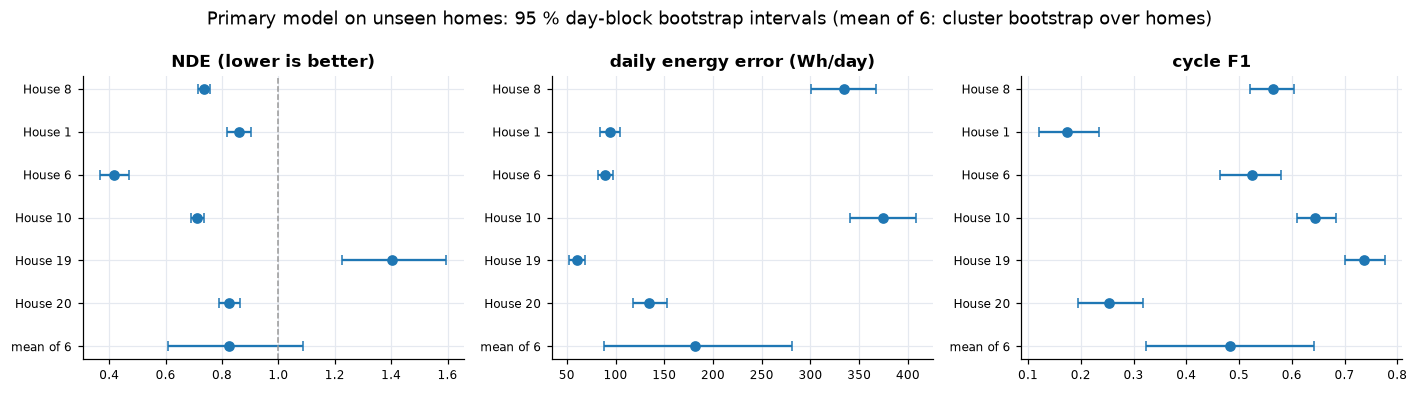

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (k, label) in zip(axes, [("nde", "NDE (lower is better)"), ("epd_wh", "daily energy error (Wh/day)"), ("cycle_f1", "cycle F1")]):
    t = ci_tab[ci_tab.metric == k].reset_index(drop=True)
    ypos = np.arange(len(t))[::-1]
    ax.errorbar(t["point"], ypos, xerr=[t["point"] - t["low"], t["high"] - t["point"]], fmt="o", capsize=3)
    ax.set_yticks(ypos, [f"House {h}" if h != "mean of 6" else "mean of 6" for h in t["house"]])
    ax.set(title=label)
    if k == "nde":
        ax.axvline(1.0, color="0.6", ls="--", lw=1)
fig.suptitle("Primary model on unseen homes: 95 % day-block bootstrap intervals (mean of 6: cluster bootstrap over homes)")
fig.tight_layout()
plots.save(fig, "nb08_ci_forest")
plt.show()

## 2. How much does the cycle metric depend on its own definition?

Cycle F1 matches a predicted wash to a true one when their time overlap (IoU) is at least 0.5. That
threshold is a convention, so I vary it. I also add a simpler event metric: a predicted wash counts
if it starts within ± k minutes of a true wash (one-to-one). The point is to see whether the
conclusions survive reasonable changes in definition.

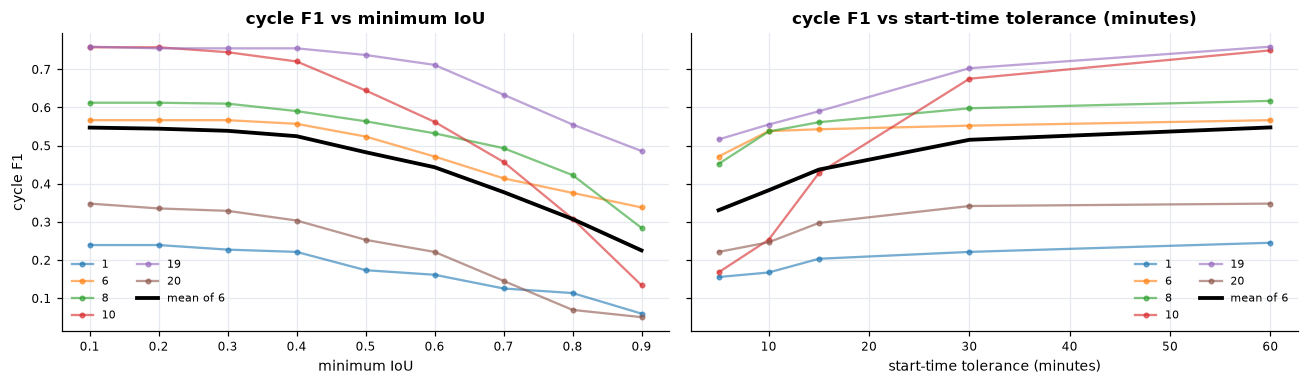

kind,IoU,start ± min
threshold,,
0.1,0.547,NaN
0.2,0.544,NaN
0.3,0.539,NaN
0.4,0.525,NaN
0.5,0.483,NaN
0.6,0.443,NaN
0.7,0.378,NaN
0.8,0.308,NaN
0.9,0.225,NaN


In [4]:
sens_rows = []
for h in UNSEEN:
    y, p = series[("test", h)]
    tc, pc = cycles.detect_cycles(y), cycles.detect_cycles(p.where(y.notna()))
    for iou in np.round(np.arange(0.1, 0.95, 0.1), 1):
        n_m = len(metrics.match_cycles(tc, pc, iou_min=iou))
        sens_rows.append({"house": h, "kind": "IoU", "threshold": iou, "f1": U.f1_from_counts(len(tc), len(pc), n_m)})
    for tol in (5, 10, 15, 30, 60):
        n_m = U.match_by_start(tc, pc, tol)
        sens_rows.append({"house": h, "kind": "start ± min", "threshold": tol, "f1": U.f1_from_counts(len(tc), len(pc), n_m)})
sens = pd.DataFrame(sens_rows)
sens.to_csv(C.TABLE_DIR / "nb08_cycle_metric_sensitivity.csv", index=False)
sens_mean = sens.groupby(["kind", "threshold"])["f1"].mean()
SUMMARY["cycle_f1_sensitivity_mean6"] = {f"{k}={t}": round(v, 3) for (k, t), v in sens_mean.items()}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, kind, xl in zip(axes, ["IoU", "start ± min"], ["minimum IoU", "start-time tolerance (minutes)"]):
    t = sens[sens.kind == kind].pivot(index="threshold", columns="house", values="f1")
    t.plot(ax=ax, marker="o", ms=3, alpha=0.6)
    t.mean(axis=1).plot(ax=ax, color="k", lw=2.5, label="mean of 6")
    ax.set(xlabel=xl, ylabel="cycle F1", title=f"cycle F1 vs {xl}")
    ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plots.save(fig, "nb08_cycle_metric_sensitivity")
plt.show()
sens_mean.unstack(0).round(3)

### Where the matching fails: start or end of a wash?

For matched washes (IoU ≥ 0.5), the absolute error of the predicted start and end times.

In [5]:
edge_rows = []
for h in UNSEEN:
    y, p = series[("test", h)]
    tc, pc = cycles.detect_cycles(y), cycles.detect_cycles(p.where(y.notna()))
    m = metrics.match_cycles(tc, pc)
    end_err = (pd.DatetimeIndex(pc.loc[m.pred_idx, "end"]) - pd.DatetimeIndex(tc.loc[m.true_idx, "end"])).total_seconds() / 60
    edge_rows.append({"house": h, "matched": len(m), "median_abs_start_error_min": float(m.start_error_min.abs().median()),
                      "median_abs_end_error_min": float(np.median(np.abs(end_err)))})
edges = pd.DataFrame(edge_rows)
edges.to_csv(C.TABLE_DIR / "nb08_matched_edge_errors.csv", index=False)
SUMMARY["matched_edge_errors_min"] = edges.set_index("house").round(1).to_dict(orient="index")
edges.round(1)

,house,matched,median_abs_start_error_min,median_abs_end_error_min
0,8,232,2.0,2.0
1,1,29,1.0,1.0
2,6,110,1.0,1.0
3,10,399,13.0,3.0
4,19,170,0.0,0.0
5,20,40,2.0,12.0


### Would another cycle definition have changed a v1 decision?

The variants in notebooks 05 and 05b were accepted or rejected on the validation home with cycle F1
at IoU ≥ 0.5. Here are the same three-seed means under all 14 definitions, so a decision that
depends on the convention would show up.

In [6]:
VARIANTS = {"Seq2Point (M2)": "m2_seq2point_w81_s{}", "gated (M3)": "m3_gated_w81_l0.1_s{}", "augmented (M4)": "m4_augdw_w81_s{}"}
DEFS = [("IoU", round(t, 1)) for t in np.arange(0.1, 0.95, 0.1)] + [("start ± min", t) for t in (5, 10, 15, 30, 60)]
yv, _ = series[("val", C.VAL_HOUSE)]
vst = cp.starts["val"]
tcv = cycles.detect_cycles(yv)
var_rows = []
for name, pattern in VARIANTS.items():
    for s in C.SEEDS:
        mdl = T.load_run(C.MODEL_DIR / (pattern.format(s) + ".pt"), device=DEVICE)[0]
        pv = D.to_series(cp, vst, T.predict(mdl, src, vst, st)["power"], C.VAL_HOUSE).reindex(yv.index)
        pc = cycles.detect_cycles(pv.where(yv.notna()))
        for kind, thr in DEFS:
            n_m = len(metrics.match_cycles(tcv, pc, iou_min=thr)) if kind == "IoU" else U.match_by_start(tcv, pc, thr)
            var_rows.append({"model": name, "seed": s, "kind": kind, "threshold": thr, "f1": U.f1_from_counts(len(tcv), len(pc), n_m)})
        del mdl
variant_rank = pd.DataFrame(var_rows).groupby(["kind", "threshold", "model"])["f1"].mean().unstack("model")
variant_rank["best"] = variant_rank.idxmax(axis=1)
variant_rank.to_csv(C.TABLE_DIR / "nb08_variant_ranking_by_definition_val.csv")
SUMMARY["variant_best_by_definition_val"] = variant_rank["best"].value_counts().to_dict()
print("best variant per definition:", SUMMARY["variant_best_by_definition_val"])
variant_rank.round(3)

best variant per definition: {'Seq2Point (M2)': 10, 'augmented (M4)': 4}


model                  Seq2Point (M2)  augmented (M4)  gated (M3)            best
kind        threshold                                                            
IoU         0.1                 0.633           0.593       0.489  Seq2Point (M2)
            0.2                 0.633           0.593       0.489  Seq2Point (M2)
            0.3                 0.633           0.593       0.489  Seq2Point (M2)
            0.4                 0.624           0.585       0.483  Seq2Point (M2)
            0.5                 0.603           0.569       0.468  Seq2Point (M2)
            0.6                 0.554           0.551       0.443  Seq2Point (M2)
            0.7                 0.483           0.488       0.399  augmented (M4)
            0.8                 0.408           0.417       0.274  augmented (M4)
            0.9                 0.239           0.282       0.133  augmented (M4)
start ± min 5.0                 0.466           0.499       0.273  augmented (M4)
            10.0                0.591           0.561       0.435  Seq2Point (M2)
            15.0                0.591           0.581       0.435  Seq2Point (M2)
            30.0                0.633           0.586       0.489  Seq2Point (M2)
            60.0                0.633           0.600       0.489  Seq2Point (M2)

## 3. Can the model find *heated* washes?

The Recommendation targets households that run many heated washes, selected with the model's
cycle detection. That claim needs its own test.

* **True heated wash:** at least 5 minutes above 1.5 kW on the plug monitor (the notebook 02
  definition).
* **Predicted heated wash:** at least 5 minutes above *P* watts in the predicted trace. The model
  under-predicts the heating block, so *P* must be lower than 1.5 kW. I choose *P* on the
  validation home (House 18) from {500, 750, 1000, 1250, 1500} W, maximising F1 of the heated label
  over matched washes (ties go to the lower, more sensitive threshold), and only then apply it to
  the test homes.
* **End-to-end heated-wash detection:** precision is the share of predicted heated washes that
  match a true heated wash. Recall is the share of true heated washes found as predicted heated
  washes. This is the quantity a targeting campaign depends on.

In [7]:
def heated_pairs(y, p, thr_w):
    tc, pc = cycles.detect_cycles(y), cycles.detect_cycles(p.where(y.notna()))
    pv = p.to_numpy()
    pc["pred_heated"] = [int(np.nansum(pv[p.index.get_loc(r.start) : p.index.get_loc(r.end) + 1] > thr_w)) >= 5 for r in pc.itertuples()]
    tc["true_heated"] = tc["minutes_over_1500w"] >= 5
    m = metrics.match_cycles(tc, pc)
    return tc, pc, m


def heated_scores(tc, pc, m):
    mt = m.assign(t=tc.loc[m.true_idx, "true_heated"].to_numpy(), p=pc.loc[m.pred_idx, "pred_heated"].to_numpy())
    tp_e2e = int((mt.t & mt.p).sum())
    n_pred_h, n_true_h = int(pc["pred_heated"].sum()), int(tc["true_heated"].sum())
    lab_tp, lab_fp, lab_fn = int((mt.t & mt.p).sum()), int((~mt.t & mt.p).sum()), int((mt.t & ~mt.p).sum())
    lab_tn = int((~mt.t & ~mt.p).sum())
    n_m = len(mt)
    prevalence = (lab_tp + lab_fn) / n_m if n_m else np.nan
    tpr = lab_tp / (lab_tp + lab_fn) if lab_tp + lab_fn else np.nan
    tnr = lab_tn / (lab_tn + lab_fp) if lab_tn + lab_fp else np.nan
    return {
        "label_f1_matched": 2 * lab_tp / (2 * lab_tp + lab_fp + lab_fn) if lab_tp + lab_fp + lab_fn else np.nan,
        # the trivial labeller that calls every matched wash heated: precision = prevalence, recall = 1
        "label_f1_all_heated_baseline": 2 * prevalence / (prevalence + 1) if n_m else np.nan,
        "label_accuracy_matched": (lab_tp + lab_tn) / n_m if n_m else np.nan,
        "label_balanced_accuracy_matched": np.nanmean([tpr, tnr]) if n_m else np.nan,
        "heated_recall_matched": tpr,
        "matched": n_m, "matched_heated": lab_tp + lab_fn,
        "e2e_precision": tp_e2e / n_pred_h if n_pred_h else np.nan,
        "e2e_recall": tp_e2e / n_true_h if n_true_h else np.nan,
        "true_heated": n_true_h, "pred_heated": n_pred_h,
    }


grid = [500, 750, 1000, 1250, 1500]
yv, pv_ = series[("val", C.VAL_HOUSE)]
val_sel = pd.DataFrame([{"P_w": g, **heated_scores(*heated_pairs(yv, pv_, g))} for g in grid])
P_W = int(val_sel.loc[val_sel["label_f1_matched"].idxmax(), "P_w"])  # ties: the lower (more sensitive) threshold
SUMMARY["heated_threshold_w_from_validation"] = P_W
print("chosen on House 18:", P_W, "W")
display(val_sel.round(3))
heat_rows = [{"house": h, **heated_scores(*heated_pairs(*series[("test", h)], P_W))} for h in UNSEEN]
heat = pd.DataFrame(heat_rows)
tot = heat[["true_heated", "pred_heated"]].sum()
heat.to_csv(C.TABLE_DIR / "nb08_heated_detection.csv", index=False)
SUMMARY["heated_detection_unseen"] = heat.set_index("house").round(3).to_dict(orient="index")
heat.round(3)

chosen on House 18: 750 W


,P_w,label_f1_matched,label_f1_all_heated_baseline,label_accuracy_matched,label_balanced_accuracy_matched,heated_recall_matched,matched,matched_heated,e2e_precision,e2e_recall,true_heated,pred_heated
0,500,0.976,0.845,0.964,0.933,1.000,56,41,0.641,0.953,43,64
1,750,0.988,0.845,0.982,0.967,1.000,56,41,0.719,0.953,43,57
2,1000,0.988,0.845,0.982,0.967,1.000,56,41,0.804,0.953,43,51
3,1250,0.923,0.845,0.893,0.906,0.878,56,41,0.878,0.837,43,41
4,1500,0.861,0.845,0.821,0.878,0.756,56,41,0.912,0.721,43,34


,house,label_f1_matched,label_f1_all_heated_baseline,label_accuracy_matched,label_balanced_accuracy_matched,heated_recall_matched,matched,matched_heated,e2e_precision,e2e_recall,true_heated,pred_heated
0,8,0.818,0.913,0.741,0.846,0.692,232,195,0.682,0.529,255,198
1,1,0.917,0.619,0.931,0.923,0.846,29,13,0.297,0.268,41,37
2,6,0.975,0.842,0.964,0.954,0.975,110,80,0.830,0.876,89,94
3,10,0.791,0.937,0.687,0.730,0.673,399,352,0.736,0.504,470,322
4,19,0.000,0.000,0.994,0.994,NaN,170,0,0.000,NaN,0,12
5,20,0.847,0.889,0.775,0.766,0.781,40,32,0.641,0.189,132,39


### Ranking homes for a targeting campaign

A campaign needs the *order* of homes by heated-wash frequency, not exact counts. I compare true
and predicted heated washes per week across every held-out period I have: the six unseen homes,
plus the later 20 % of each of the seven training homes (seen homes, a different period from
training). Spearman's rank correlation measures whether the model puts the heavy hot-wash homes
first.

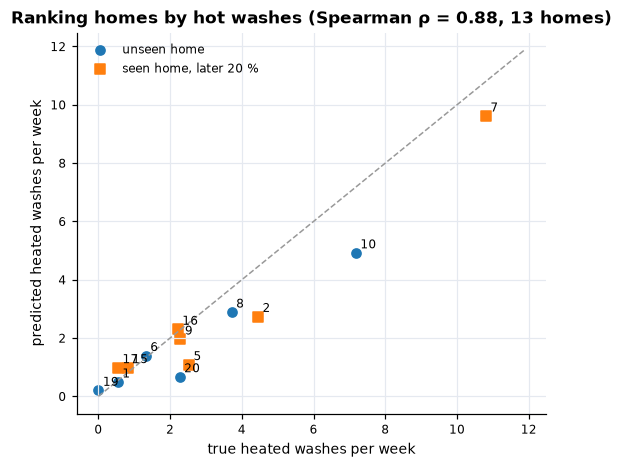

Spearman rho: all 13 homes 0.88; unseen 6 homes 0.94; without the two heaviest users 0.80


,house,period,true_heated_per_week,pred_heated_per_week,weeks
0,8,unseen home,3.72,2.88,68.64
1,1,unseen home,0.54,0.49,75.65
2,6,unseen home,1.32,1.39,67.40
3,10,unseen home,7.18,4.92,65.48
4,19,unseen home,0.00,0.20,59.33
5,20,unseen home,2.26,0.67,58.28
6,2,"seen home, later 20 %",4.45,2.74,14.61
7,5,"seen home, later 20 %",2.53,1.08,13.86
8,7,"seen home, later 20 %",10.80,9.61,12.59
9,9,"seen home, later 20 %",2.29,1.96,12.25


In [8]:
trows = []
for (split, h), (y, p) in series.items():
    if split == "val":
        continue
    tc, pc, _ = heated_pairs(y, p, P_W)
    weeks = y.notna().sum() / (7 * 1440)
    trows.append({"house": h, "period": "unseen home" if split == "test" else "seen home, later 20 %",
                  "true_heated_per_week": tc["true_heated"].sum() / weeks, "pred_heated_per_week": pc["pred_heated"].sum() / weeks,
                  "weeks": weeks})
target = pd.DataFrame(trows)
rho_all = spearmanr(target.true_heated_per_week, target.pred_heated_per_week).statistic
unseen_t = target[target.period == "unseen home"]
rho_unseen = spearmanr(unseen_t.true_heated_per_week, unseen_t.pred_heated_per_week).statistic
target.to_csv(C.TABLE_DIR / "nb08_targeting.csv", index=False)
lighter = target.drop(target.true_heated_per_week.nlargest(2).index)
rho_light = spearmanr(lighter.true_heated_per_week, lighter.pred_heated_per_week).statistic
SUMMARY["targeting_spearman"] = {"all_13_homes": round(float(rho_all), 3), "unseen_6_homes": round(float(rho_unseen), 3),
                                "without_two_heaviest": round(float(rho_light), 3)}
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for per, mk in [("unseen home", "o"), ("seen home, later 20 %", "s")]:
    t = target[target.period == per]
    ax.scatter(t.true_heated_per_week, t.pred_heated_per_week, marker=mk, label=per)
    for r in t.itertuples():
        ax.annotate(str(r.house), (r.true_heated_per_week, r.pred_heated_per_week), fontsize=8, xytext=(3, 3), textcoords="offset points")
lim = max(target.true_heated_per_week.max(), target.pred_heated_per_week.max()) * 1.1
ax.plot([0, lim], [0, lim], color="0.6", ls="--", lw=1)
ax.set(xlabel="true heated washes per week", ylabel="predicted heated washes per week",
       title=f"Ranking homes by hot washes (Spearman ρ = {rho_all:.2f}, 13 homes)")
ax.legend(fontsize=8)
plots.save(fig, "nb08_targeting")
plt.show()
print(f"Spearman rho: all 13 homes {rho_all:.2f}; unseen 6 homes {rho_unseen:.2f}; without the two heaviest users {rho_light:.2f}")
target.round(2)

## 4. The two numbers a utility would quote

* **Peak share:** the share of washing-machine energy used 16:00–19:00 local time, true vs
  predicted, per home.
* **Monthly energy error:** |predicted − true| / true washing energy per calendar month, over months
  with at least 20 well-covered days.

In [9]:
brows = []
for h in UNSEEN:
    y, p = series[("test", h)]
    ok = y.notna() & p.notna()
    local_hour = y.index.tz_convert(C.LOCAL_TZ).hour
    peak = (local_hour >= 16) & (local_hour < 19)
    share = lambda s: 100 * s[ok & peak].sum() / s[ok].sum()  # noqa: E731
    dd = metrics.daily_energy_errors(y, p)
    month = dd.groupby(dd.index.tz_convert(None).to_period("M")).agg(days=("y_kwh", "size"), y=("y_kwh", "sum"), yhat=("yhat_kwh", "sum"))
    month = month[month.days >= 20]
    ape = 100 * (month.yhat - month.y).abs() / month.y
    brows.append({"house": h, "true_peak_share_pct": share(y), "pred_peak_share_pct": share(p),
                  "months": len(month), "monthly_energy_ape_median_pct": ape.median(), "monthly_energy_ape_max_pct": ape.max()})
biz = pd.DataFrame(brows)
biz["peak_share_error_pp"] = biz.pred_peak_share_pct - biz.true_peak_share_pct
biz.to_csv(C.TABLE_DIR / "nb08_business_metrics.csv", index=False)
SUMMARY["business_unseen"] = biz.set_index("house").round(2).to_dict(orient="index")
SUMMARY["peak_share_error_pp_mean"] = round(float(biz.peak_share_error_pp.mean()), 2)
# portfolio view: sum the six homes' well-covered days per calendar month; keep months with >= 4 homes x >= 20 days
daily = pd.concat({h: metrics.daily_energy_errors(*series[("test", h)]) for h in UNSEEN}, names=["house", "day"]).reset_index()
daily["month"] = daily.day.dt.tz_convert(None).dt.to_period("M")
per_hm = daily.groupby(["month", "house"]).agg(days=("y_kwh", "size"), y=("y_kwh", "sum"), yhat=("yhat_kwh", "sum")).reset_index()
per_hm = per_hm[per_hm.days >= 20]
pooled = per_hm.groupby("month").agg(homes=("house", "nunique"), y=("y", "sum"), yhat=("yhat", "sum"))
pooled = pooled[pooled.homes >= 4]
pooled_ape = 100 * (pooled.yhat - pooled.y).abs() / pooled.y
SUMMARY["pooled_monthly_energy"] = {"months": int(len(pooled)), "ape_median_pct": round(float(pooled_ape.median()), 1),
                                    "ape_max_pct": round(float(pooled_ape.max()), 1),
                                    "r_true_vs_pred": round(float(np.corrcoef(pooled.y, pooled.yhat)[0, 1]), 3),
                                    "pred_over_true_total": round(float(pooled.yhat.sum() / pooled.y.sum()), 3),
                                    "months_under_predicted": int((pooled.yhat < pooled.y).sum())}
# month-to-month change, on the same homes in both months (>= 4 homes), as a before/after study would use it
pairs = []
months = sorted(per_hm.month.unique())
for m1, m2 in zip(months[:-1], months[1:]):
    if (m2 - m1).n != 1:
        continue
    homes = sorted(set(per_hm[per_hm.month == m1].house) & set(per_hm[per_hm.month == m2].house))
    if len(homes) < 4:
        continue
    a = per_hm[(per_hm.month == m1) & per_hm.house.isin(homes)][["y", "yhat"]].sum()
    b = per_hm[(per_hm.month == m2) & per_hm.house.isin(homes)][["y", "yhat"]].sum()
    pairs.append({"from": str(m1), "to": str(m2), "homes": len(homes),
                  "true_change_pct": 100 * (b.y / a.y - 1), "pred_change_pct": 100 * (b.yhat / a.yhat - 1)})
change = pd.DataFrame(pairs)
change.to_csv(C.TABLE_DIR / "nb08_monthly_change.csv", index=False)
same_sign = np.sign(change.true_change_pct) == np.sign(change.pred_change_pct)
SUMMARY["monthly_change"] = {"pairs": int(len(change)),
                             "mae_pp": round(float((change.pred_change_pct - change.true_change_pct).abs().mean()), 1),
                             "same_direction": int(same_sign.sum()),
                             "median_abs_true_change_pct": round(float(change.true_change_pct.abs().median()), 1),
                             "median_abs_pred_change_pct": round(float(change.pred_change_pct.abs().median()), 1)}
print("mean peak-share error (pp):", SUMMARY["peak_share_error_pp_mean"])
print("pooled monthly energy, >= 4 homes:", SUMMARY["pooled_monthly_energy"])
print("month-to-month change:", SUMMARY["monthly_change"])
biz.round(1)

mean peak-share error (pp): 7.87
pooled monthly energy, >= 4 homes: {'months': 14, 'ape_median_pct': 19.8, 'ape_max_pct': 33.5, 'r_true_vs_pred': 0.886, 'pred_over_true_total': 0.799, 'months_under_predicted': 13}
month-to-month change: {'pairs': 13, 'mae_pp': 11.2, 'same_direction': 12, 'median_abs_true_change_pct': 20.3, 'median_abs_pred_change_pct': 15.7}


,house,true_peak_share_pct,pred_peak_share_pct,months,monthly_energy_ape_median_pct,monthly_energy_ape_max_pct,peak_share_error_pp
0,8,0.6,4.2,17,26.299999,36.700001,3.7
1,1,2.3,18.1,15,19.299999,243.100006,15.8
2,6,3.5,8.4,16,21.500000,68.599998,4.9
3,10,11.1,14.4,16,35.299999,337.100006,3.3
4,19,6.6,24.1,14,51.299999,123.099998,17.5
5,20,6.5,8.5,13,27.900000,41.700001,2.0


In [10]:
(C.METRIC_DIR / "nb08_summary.json").write_text(json.dumps(SUMMARY, indent=2, default=float))
print("saved", sorted(SUMMARY))

saved ['business_unseen', 'ci', 'ci_7day_blocks', 'ci_width_ratio_7day_vs_day', 'cycle_f1_sensitivity_mean6', 'heated_detection_unseen', 'heated_threshold_w_from_validation', 'matched_edge_errors_min', 'monthly_change', 'n_boot', 'nde_spread_unseen', 'peak_share_error_pp_mean', 'pooled_monthly_energy', 'targeting_spearman', 'unseen_homes', 'variant_best_by_definition_val']


## Summary

**Intervals (95 %: day-block bootstrap within a home; cluster bootstrap over homes for the six-home average).**

| | NDE | daily energy error (Wh/day) | cycle F1 |
|---|---|---|---|
| House 8 | 0.737 (0.716–0.757) | 335 (301–367) | 0.564 (0.521–0.604) |
| average of the six unseen homes | 0.825 (0.607–1.087) | 181 (88–281) | 0.483 (0.324–0.642) |

**Within a home.** A year and more of days pins NDE and the daily energy error down tightly in five
of the six homes. House 19's NDE (1.22–1.60) is the exception. Cycle F1 is looser where few washes
are matched: House 1, 29 of 93 true washes matched, 0.12–0.23; House 20, 40 of 218, 0.19–0.32.
Resampling week-long runs of days instead of single days widens the intervals by a median of 7 %,
and at most 47 % (House 1's daily energy error). One-day blocks therefore capture most of the
dependence in the data, but not all of it.

**Between homes is where the uncertainty lies.** The interval above is for the *average* over homes
like these. A single new home can land far from it. The six homes range from NDE 0.42 to 1.40
(SD 0.32), and one of the six is worse than predicting zero. More test homes would narrow the
interval for the average, but not this home-to-home spread. Five of six homes below NDE 1.0 is good
evidence that the model helps in a typical home. Six homes are not enough to make it conclusive.

**The cycle metric's own definition.** Mean cycle F1 over the six homes is 0.55 at IoU ≥ 0.1, 0.48
at the standard 0.5 and 0.23 at 0.9. Matched by start time instead, it is 0.38 within ±10 minutes
and 0.52 within ±30. Matched washes are usually placed within a few minutes at both ends (medians of
0–3 minutes), with two exceptions: House 10's predicted starts are a median 13 minutes off, and
House 20's ends 12 minutes.

**Would another definition have changed a v1 decision?** On the validation home Seq2Point (M2) has
the best three-seed cycle F1 under 10 of the 14 definitions, including the standard one. The
augmented model (M4) has the higher mean under the other four, IoU ≥ 0.7, 0.8 and 0.9 and starts
within ±5 minutes:
* at IoU 0.7 and 0.8 it leads by 0.005 and 0.009, inside M2's seed spread of 0.016, which notebook
  05b's rule required it to exceed;
* at IoU 0.9 and ±5 minutes it leads by 0.043 and 0.033.

I did not compute seed spreads per definition, so I cannot say whether the 05b rule would have
accepted M4 under those two. The gated model (M3) is last under every definition.

**Heated washes.** I chose the 750 W threshold on House 18. Among the washes the model finds, the
heated/unheated label is right 69–96 % of the time, with balanced accuracy 0.73–0.95 in the five
homes that heat water. Two weaknesses remain:
* At this threshold it calls about a third of the truly heated washes unheated in Houses 8 and 10
  (heated recall 0.69 and 0.67).
* Its F1 beats the trivial labeller that calls every wash heated only in Houses 1 and 6.

End to end, it finds 19–88 % of true heated washes depending on the home, and 30–83 % of its heated
detections are real. House 19 had no heated wash in its test period (by the notebook 02 definition)
and gets 12 false heated washes over 59 weeks.

**Targeting works by rank.** The model under-counts hot washes (House 10: 4.9 predicted against 7.2
true per week) but orders homes well. Spearman ρ is 0.94 over the six unseen homes, 0.88 over all 13
held-out periods, and 0.80 without the two heaviest users. These are few homes, so the figures are
indicative. A campaign that picks homes by predicted hot-wash frequency would largely pick the right
ones.

**Peak share is overstated.** The model puts 2–18 percentage points too much washing energy into
16:00–19:00 (mean +7.9 points; worst in Houses 19 and 1). This is consistent with false cycles from
other large loads, which notebook 06 attributed appliance by appliance in House 8; I have not
attributed them in these homes. Peak-hour shares from the model need correcting against
plug-metered homes before use, and I changed `Recommendation.md` accordingly.

**Monthly energy.**
* *Per home:* the median monthly error is 19–51 %, and single months are off by more than 300 %
  (House 10).
* *Summed over the homes available each month* (at least four; 14 months): the median error is
  20 % and the largest 34 %, and true and predicted totals correlate at r = 0.89.
* *The pooled level is biased:* predicted energy is 20 % low overall and below the truth in 13 of
  the 14 months.
* *Month-to-month changes over the same homes* (13 pairs of consecutive months) go the right way
  12 times. The model damps them (median size 16 % predicted against 20 % true), with a mean
  error of 11 percentage points.

So errors partly cancel across this set of homes. A portfolio can track the direction of monthly
change, but its level runs low. I did not test other mixes of homes.

## Verification log

* The point estimates recomputed here equal notebook 06 to four decimals for all six homes (NDE,
  cycle F1, daily error).
* `tests/test_uncertainty.py` checks that the day-level statistics reproduce the point metrics
  exactly, including when the prediction has a gap across a whole wash or a whole day.
* The heated threshold was chosen on House 18 only, where 750 W and 1,000 W tied on the selection
  metric. My first run broke the tie by table order; I then made the rule explicit in the code (the
  lower, more sensitive threshold), which gives the same choice.
* Visual: the forest plot puts House 19 alone above NDE 1.0. In the targeting scatter most homes sit
  on or below the diagonal (under-counting); the furthest below are Houses 10, 2, 20 and 5.